# Impact Split Explainer

This notebook tells the development story of `impact-split` as a new approach for additive KPIs.

Flow of this notebook:

1. Why this problem needs a different lens
2. The working mathematical frame used in this notebook
3. A toy scenario with a documented synthetic DGP (expected impact, bias, noise, observed outcome)
4. What to inspect in the generated tree and segments
5. How parameter choices change what we see

If you only need a high-level summary, use the README. This notebook is the deeper walkthrough.

## 1) Problem Framing

For additive KPIs, a useful question is often:

> Which segments contribute the most to total outcome (positive or negative)?

A simple intuition:

- Segment A: 2 users x -500 average = -1,000 total
- Segment B: 10,000 users x -40 average = -400,000 total

This notebook uses that framing to motivate the approach explored below.

## 2) Working Mathematical Frame

The definitions below describe the frame used in this notebook run.

### A. Local Sieve (`delta`)

At each node:

$$
V_{node} = \sum_{j=1}^{N_{node}} |y_j|
$$

$$
\delta = V_{node} \times \text{delta\_pct}
$$

For each category in feature $X_i$:

$$
S_{cat} = \sum_{y \in cat} y
$$

Routing rule in this frame:

- Positive if $S_{cat} > \delta$
- Negative if $S_{cat} < -\delta$
- Neutral otherwise

**Implementation:** with default `neutral_root=True`, the **root** uses $\delta = 0$ for this routing (categories split by the sign of $S_{cat}$); deeper nodes use $\delta = V_{node} \times \text{delta\_pct}$. Use `neutral_root=False` to apply the scaled $\delta$ at every depth.

### B. Split Metric

$$
Gain(X_i) = \frac{|S_P|}{k_P} + \frac{|S_N|}{k_N}
$$

Where $S_P, S_N$ are outer-branch sums and $k_P, k_N$ are the number of categories assigned to each outer branch.

### C. Global Stopping Rule

Let:

$$
V_{global\_P} = \sum_{y_i > 0} y_i,
\quad
V_{global\_N} = \sum_{y_i < 0} |y_i|
$$

At each node:

$$
S_{node\_P} = \sum_{y_i \in node, y_i > 0} y_i,
\quad
S_{node\_N} = \sum_{y_i \in node, y_i < 0} |y_i|
$$

Continue splitting only if either ratio is above `min_global_impact_pct`:

- $S_{node\_P} / V_{global\_P}$
- $S_{node\_N} / V_{global\_N}$

Parameter mapping used later in code:

- `delta_pct` controls the local sieve width (`delta`) at non-root nodes (and `delta_nominal` everywhere for trace)
- `neutral_root` (default `True`) uses $\delta=0$ at the root for routing only
- `min_global_impact_pct` controls the global stop threshold

In [1]:
import numpy as np
import pandas as pd

from impact_split import ImpactSplitter

2026-03-27 14:14:42.102 | INFO     | impact_split.config:<module>:11 - PROJ_ROOT path is: /Users/juedimyroeugenio/Documents/Projects/impact-split


## 3) Synthetic data (DGP)

We simulate a **documented** data-generating process so we can compare *what we planted* with *what the tree finds*:

- **`y_expected`** — structural contribution from known business rules (region × channel × product interactions only). This is the "expected" driver we care about for attribution.
- **`bias`** — extra profit/loss that depends on **region** alone (e.g. market size / composition). It is **not** part of the interaction rules; it can make marginal channel or region totals look stronger or weaker than the structural story alone.
- **`epsilon`** — iid noise around each row.

We **fit the tree on `y_observed = y_expected + bias + epsilon`** only, so the exercise matches a realistic setting where you observe one outcome, not the decomposition.

*(Analogy: libraries like [CausalML](https://causalml.readthedocs.io/en/latest/_modules/causalml/dataset/synthetic.html) separate outcome into true effect, bias, and propensity for uplift simulations; here we use the same additive decomposition idea for an additive KPI.)*

`ImpactSplitter` expects **integer label-encoded** features: we build `X_np` and keep `category_maps` so you can decode node labels `f0`, `f1`, `f2` in the plot (`f0` = region, `f1` = channel, `f2` = product).

In [2]:
# Build a toy scenario for illustration (not a claim about real data)
rng = np.random.default_rng(42)
n = 5000

regions = np.array(["NCR", "Luzon", "Visayas", "Mindanao"])
channels = np.array(["Direct", "Partner", "Online"])
products = np.array(["A", "B", "C"])

X_df = pd.DataFrame(
    {
        "region": rng.choice(regions, size=n, p=[0.35, 0.3, 0.2, 0.15]),
        "channel": rng.choice(channels, size=n, p=[0.25, 0.35, 0.4]),
        "product": rng.choice(products, size=n, p=[0.4, 0.35, 0.25]),
    }
)

# Structural "expected" impact — the only deliberate interaction rules we care to recover.
y_expected = (
    np.where((X_df["region"] == "NCR") & (X_df["channel"] == "Direct"), 120, 0)
    + np.where((X_df["region"] == "Mindanao") & (X_df["product"].isin(["A", "B"])), -95, 0)
    + np.where((X_df["channel"] == "Online") & (X_df["product"] == "C"), 35, 0)
).astype(np.float64)

# Region-only bias (composition / market effects), not part of the interaction rules above.
region_bias = np.array([55.0, 12.0, -8.0, -35.0], dtype=np.float64)
region_codes = pd.Categorical(X_df["region"], categories=regions).codes
bias = region_bias[region_codes]

epsilon = rng.normal(loc=0, scale=35, size=n)
y_observed = y_expected + bias + epsilon

# Integer label encoding required by ImpactSplitter.fit (same category order as arrays above).
channel_codes = pd.Categorical(X_df["channel"], categories=channels).codes
product_codes = pd.Categorical(X_df["product"], categories=products).codes
X_np = np.column_stack([region_codes, channel_codes, product_codes]).astype(np.int64)

category_maps = {
    0: {i: lab for i, lab in enumerate(regions)},
    1: {i: lab for i, lab in enumerate(channels)},
    2: {i: lab for i, lab in enumerate(products)},
}
feature_names = ["region", "channel", "product"]

# Expected vs observed totals on hand-picked slices (same rules as y_expected).
slice_defs = [
    ("NCR × Direct", (X_df["region"] == "NCR") & (X_df["channel"] == "Direct")),
    ("Mindanao × {A,B}", (X_df["region"] == "Mindanao") & (X_df["product"].isin(["A", "B"]))),
    ("Online × C", (X_df["channel"] == "Online") & (X_df["product"] == "C")),
]
rows = []
for label, mask in slice_defs:
    rows.append(
        {
            "slice": label,
            "n": int(mask.sum()),
            "sum_y_expected": float(y_expected[mask].sum()),
            "sum_y_observed": float(y_observed[mask].sum()),
        }
    )
pd.DataFrame(rows)

,slice,n,sum_y_expected,sum_y_observed
0,NCR × Direct,470,56400.0,82064.853758
1,"Mindanao × {A,B}",551,-52345.0,-70768.835181
2,Online × C,495,17325.0,25803.087502


In [3]:
# 4) Fit one baseline configuration for exploration (observed outcome only)
y_fit = y_observed.astype(np.float64, copy=False)

model = ImpactSplitter(
    delta_pct=0.05,
    min_global_impact_pct=0.01,
    max_depth=4,
)

model.fit(X_np, y_fit)

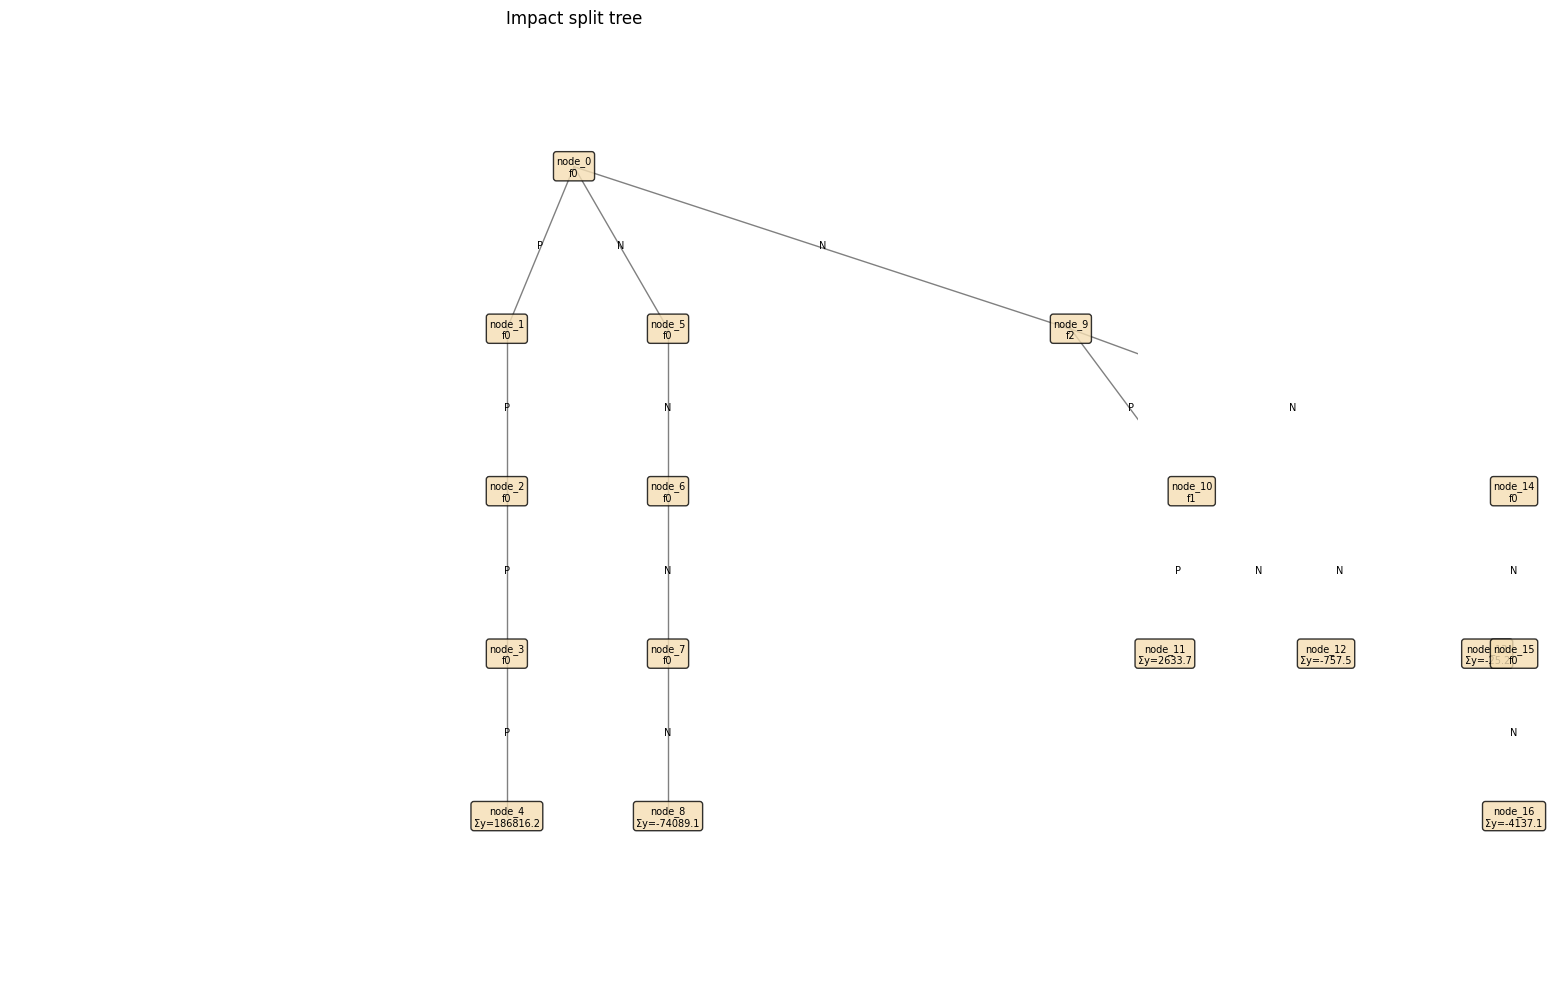

In [4]:
# Inspect the split structure produced by the baseline run.
model.plot_tree(figsize=(16, 10))

In [5]:
# Inspect top segments and compare them with the structural rules (y_expected) and the DGP.
segments = model.get_impact_segments()

print(
    "Global sum(y_expected) =",
    float(y_expected.sum()),
    "| Global sum(y_observed) =",
    float(y_observed.sum()),
)
planted = {label: float(y_expected[mask].sum()) for label, mask in slice_defs}
print("Planted structural totals (y_expected on each slice):", planted)

segments.head(15)

Global sum(y_expected) = 21380.0 | Global sum(y_observed) = 110441.04808633399
Planted structural totals (y_expected on each slice): {'NCR × Direct': 56400.0, 'Mindanao × {A,B}': -52345.0, 'Online × C': 17325.0}


,path,total_sum,n_samples,node_id
0,root / f0=positive / f0=positive / f0=positive...,186816.223010,3283,node_4
1,root / f0=negative / f0=negative / f0=negative...,-74089.100324,745,node_8
2,root / f0=neutral / f2=negative / f0=negative ...,-4137.084188,738,node_16
3,root / f0=neutral / f2=positive / f1=positive,2633.712073,98,node_11
4,root / f0=neutral / f2=positive / f1=negative,-757.456070,84,node_12
5,root / f0=neutral / f2=positive / f1=neutral,-25.246414,52,node_13


### Reading the segments

The tree is fit on **`y_observed`**, so leaf `total_sum` values are **not** numerically equal to sums of `y_expected` on the same slice (noise and region **bias** shift row-level outcomes). You should still see **large-magnitude** leaves align with the **interaction rules** we planted (NCR×Direct positive, Mindanao×{A,B} negative, Online×C positive), because those patterns drive pooled category sums. Decode `f0` / `f1` / `f2` in `plot_tree` with `category_maps` (`f0` = region, `f1` = channel, `f2` = product).

## 5) Parameter Exploration

This section is intentionally exploratory.

Rather than assume one "correct" setting, compare how the output changes when we vary:

- `delta_pct` (local sieve width)
- `min_global_impact_pct` (global materiality stop)

Suggested reading questions:

- Which segments stay stable across runs?
- Which segments appear only under more aggressive settings?
- How does tree complexity change?

In [6]:
# Run a small comparison grid and review differences in top segments.
for delta_pct, min_global_impact_pct in [(0.03, 0.01), (0.05, 0.01), (0.08, 0.02)]:
    m = ImpactSplitter(
        delta_pct=delta_pct,
        min_global_impact_pct=min_global_impact_pct,
        max_depth=4,
    )
    m.fit(X_np, y_fit)
    top = m.get_impact_segments().head(3)
    print(f"delta_pct={delta_pct}, min_global_impact_pct={min_global_impact_pct}")
    print(top[["path", "total_sum"]] if {"path", "total_sum"}.issubset(top.columns) else top)
    print("-" * 80)

delta_pct=0.03, min_global_impact_pct=0.01
                                                path      total_sum
0  root / f0=positive / f0=positive / f0=positive...  186816.223010
1  root / f0=negative / f0=negative / f0=negative...  -74089.100324
2  root / f0=neutral / f2=negative / f0=negative ...   -4137.084188
--------------------------------------------------------------------------------
delta_pct=0.05, min_global_impact_pct=0.01
                                                path      total_sum
0  root / f0=positive / f0=positive / f0=positive...  186816.223010
1  root / f0=negative / f0=negative / f0=negative...  -74089.100324
2  root / f0=neutral / f2=negative / f0=negative ...   -4137.084188
--------------------------------------------------------------------------------
delta_pct=0.08, min_global_impact_pct=0.02
                                                path      total_sum
0  root / f0=positive / f0=positive / f0=positive...  164060.481894
1  root / f0=negative / f0=ne